 ### Áp dụng Conformance Checking chuẩn mực (Token Replay)
- Thay vì dùng "Edit Distance" (khoảng cách chuỗi) để tính độ tương đồng với Happy Path như hiện tại (đây chỉ là cách xấp xỉ).
- Mục tiêu: Sử dụng thuật toán Token-based Replay hoặc Alignments của thư viện pm4py để đối chiếu từng hồ sơ thực tế với mô hình chuẩn (Petri net) xem nó vi phạm quy tắc ở bước nào.

In [6]:
import pandas as pd
import pm4py
import random
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
print("Đang đọc dữ liệu...")
df = pd.read_csv('../data/bpi-challenge-2017/bpi_2017_cleaned.csv')
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed')

# 2. Lấy mẫu 2000 cases ngẫu nhiên để tiết kiệm RAM và thời gian chạy
all_cases = df['case:concept:name'].unique()
random.seed(42) # Cố định seed để kết quả không thay đổi sau mỗi lần chạy
sample_cases = random.sample(list(all_cases),3000)

df_sample = df[df['case:concept:name'].isin(sample_cases)].copy()

# 3. Format dữ liệu cho pm4py
df_sample = pm4py.format_dataframe(df_sample, 
                                   case_id='case:concept:name', 
                                   activity_key='concept:name', 
                                   timestamp_key='time:timestamp')

print(f"Đã chuẩn bị xong dữ liệu mẫu với {len(df_sample)} sự kiện.")


Đang đọc dữ liệu...
Đã chuẩn bị xong dữ liệu mẫu với 114000 sự kiện.


In [7]:
print("Đang xây dựng Petri Net bằng Inductive Miner...")

# Sử dụng thuật toán Inductive Miner (tạo ra mô hình rất chặt chẽ về mặt logic)
# Ở đây ta dùng tham số noise_threshold để lọc bớt các nhiễu rác (những đường đi quá hiếm)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(df_sample, noise_threshold=0.2)

# Trực quan hóa mạng Petri (nếu bạn muốn xem thử)
# pm4py.view_petri_net(net, initial_marking, final_marking)

print("Xây dựng mô hình chuẩn thành công!")


Đang xây dựng Petri Net bằng Inductive Miner...
Xây dựng mô hình chuẩn thành công!


In [8]:
print("Bắt đầu chạy Token-based Replay (Có thể mất 1-3 phút)...")

# Chạy thuật toán Token-based Replay
replayed_traces = pm4py.conformance_diagnostics_token_based_replay(df_sample, net, initial_marking, final_marking)

print("Đã chạy xong!")


Bắt đầu chạy Token-based Replay (Có thể mất 1-3 phút)...


replaying log with TBR, completed traces ::   0%|          | 0/2002 [00:00<?, ?it/s]

Đã chạy xong!


=== KẾT QUẢ CONFORMANCE CHECKING ===
✅ Độ phù hợp trung bình (Average Fitness): 99.29%
✅ Tỷ lệ hồ sơ tuân thủ hoàn hảo 100%: 65.70%


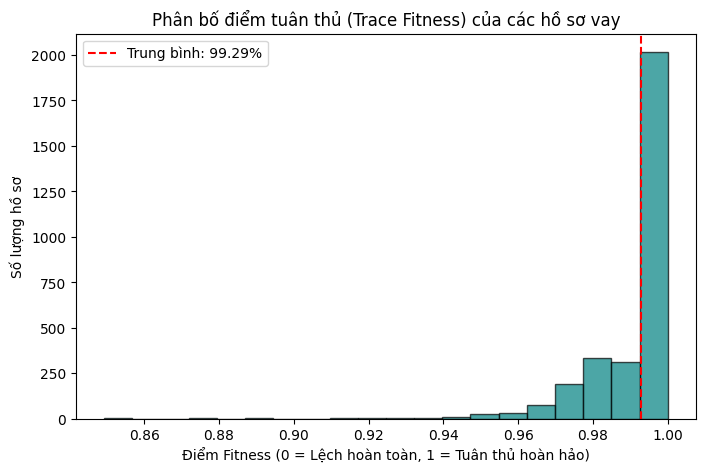

In [9]:
# Trích xuất điểm Fitness của từng case
fitness_scores = [trace['trace_fitness'] for trace in replayed_traces]
is_fit = [trace['trace_is_fit'] for trace in replayed_traces]

# Tính trung bình
average_fitness = sum(fitness_scores) / len(fitness_scores)
perfect_fit_ratio = sum(is_fit) / len(is_fit)

print("=== KẾT QUẢ CONFORMANCE CHECKING ===")
print(f"✅ Độ phù hợp trung bình (Average Fitness): {average_fitness:.2%}")
print(f"✅ Tỷ lệ hồ sơ tuân thủ hoàn hảo 100%: {perfect_fit_ratio:.2%}")

# Vẽ biểu đồ phân bố điểm Fitness
plt.figure(figsize=(8, 5))
plt.hist(fitness_scores, bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Phân bố điểm tuân thủ (Trace Fitness) của các hồ sơ vay')
plt.xlabel('Điểm Fitness (0 = Lệch hoàn toàn, 1 = Tuân thủ hoàn hảo)')
plt.ylabel('Số lượng hồ sơ')
plt.axvline(x=average_fitness, color='red', linestyle='--', label=f'Trung bình: {average_fitness:.2%}')
plt.legend()
plt.show()
